# Recipe clustering (HDBSCAN)

Features per recipe (`input_stage2/price_mapped_nutrients.csv`):
- **product** embedding (mean of lemmatized product phrases), block weight **1.5×**
- **adj + verb** embedding (mean of lemmatized descriptor tokens)
- **nutrients** (log1p, standardized)
- **total price** as an interval: sum of priced items, **±3 per unpriced item** → `[price_lo, price_hi]`

Each block is scaled to unit total variance before weighting, so the weights mean what they say regardless of dimensionality.
Pipeline: features → UMAP (10-d) → HDBSCAN, with a 2-d UMAP used only for plotting.

In [1]:
import ast, re, os, json, hashlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sentence_transformers import SentenceTransformer
import umap

SEED = 42
UNPRICED_BAND = 3.0      # ± per unpriced item
WEIGHTS = {'product': 1.5, 'adj_verb': 1.0, 'nutrients': 1.0, 'price': 1.0}
PCA_DIMS = {'product': 32, 'adj_verb': 16}     # blocks not listed are used as-is
ENCODER_NAME = 'Qwen/Qwen3-Embedding-0.6B'
ARTIFACT_DIR = 'model_artifacts/recipe_clustering'
NUTRIENTS = ['protein_g', 'fat_g', 'carb_g', 'energy_kcal', 'fiber_g', 'sodium_mg',
             'cholesterol_mg', 'satfat_g', 'sugars_g']

for pkg in ['wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

LIST_COLS = ['product', 'unpriced_items', 'adj', 'verb', 'item_prices']

def parse_lists(frame):
    frame = frame.copy()
    for c in LIST_COLS:
        frame[c] = frame[c].apply(lambda v: ast.literal_eval(v) if isinstance(v, str) else v)
    return frame

df = parse_lists(pd.read_csv('input_stage2/price_mapped_nutrients.csv'))
df.shape

(10845, 20)

## 1. Token normalization + lemmatization

In [2]:
lemmatizer = WordNetLemmatizer()

def _words(text):
    return re.findall(r'[a-z]+', text.lower())

def norm_phrase(phrase):
    # product phrases: lemmatize every word as a noun ("layer buttermilk biscuits" -> "layer buttermilk biscuit")
    return ' '.join(lemmatizer.lemmatize(w, 'n') for w in _words(phrase))

def norm_adj(tok):
    return ' '.join(lemmatizer.lemmatize(w, 'a') for w in _words(tok))

def norm_verb(tok):
    # participles like "frozen"/"refrigerated" -> "freeze"/"refrigerate"
    return ' '.join(lemmatizer.lemmatize(w, 'v') for w in _words(tok))

def uniq(xs):
    return list(dict.fromkeys(x for x in xs if x))

def normalize_tokens(frame):
    frame['product_norm'] = frame['product'].apply(lambda xs: uniq(norm_phrase(x) for x in xs))
    frame['desc_norm'] = frame.apply(lambda r: uniq([norm_adj(a) for a in r['adj']] + [norm_verb(v) for v in r['verb']]), axis=1)
    return frame

df = normalize_tokens(df)

for col, raw in [('product_norm', 'product'), ('desc_norm', None)]:
    before = len({t for xs in (df[raw] if raw else df['adj'] + df['verb']) for t in xs})
    after = len({t for xs in df[col] for t in xs})
    print(f'{col}: {before} raw tokens -> {after} normalized')
df[['description', 'product_norm', 'desc_norm']].head(8)

product_norm: 2443 raw tokens -> 2307 normalized
desc_norm: 738 raw tokens -> 577 normalized


,description,product_norm,desc_norm
0,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","[layer buttermilk biscuit, dough]","[golden, artificial, refrigerate]"
1,"Waffles, buttermilk, frozen, ready-to-heat",[waffle],"[ready, freeze]"
2,"Waffle, buttermilk, frozen, ready-to-heat, toa...",[waffle],"[ready, freeze, toast]"
3,"Waffle, buttermilk, frozen, ready-to-heat, mic...",[waffle],"[ready, freeze, microwave]"
4,"Waffle, plain, frozen, ready-to-heat, microwave",[waffle],"[plain, ready, freeze]"
5,"Pie Crust, Cookie-type, Graham Cracker, Ready ...","[pie crust, cookie type, graham cracker]",[ready]
6,"Pie, Dutch Apple, Commercially Prepared","[pie, apple]","[dutch, prepare]"
7,"Waffles, chocolate chip, frozen, ready-to-heat",[waffle],"[ready, freeze]"


## 2. Price interval (±3 per unpriced item)

`total_price` in the CSV is 0 whenever any item is unpriced, so it is recomputed from `item_prices`.

In [3]:
def add_price_interval(frame):
    frame['n_unpriced'] = frame['unpriced_items'].str.len()
    frame['price_mid'] = frame['item_prices'].apply(lambda d: float(sum(d.values())))
    frame['price_lo'] = (frame['price_mid'] - UNPRICED_BAND * frame['n_unpriced']).clip(lower=0)
    frame['price_hi'] = frame['price_mid'] + UNPRICED_BAND * frame['n_unpriced']
    return frame

df = add_price_interval(df)
df[['price_mid', 'price_lo', 'price_hi', 'n_unpriced']].describe().round(2)

,price_mid,price_lo,price_hi,n_unpriced
count,10845.00,10845.00,10845.00,10845.00
mean,14.62,13.95,15.31,0.23
std,20.20,20.27,20.22,0.48
min,0.47,0.00,0.47,0.00
25%,4.54,4.17,5.00,0.00
50%,8.50,8.00,9.50,0.00
75%,15.87,14.95,16.65,0.00
max,206.57,203.57,209.57,4.00


## 3. Embeddings (embed each unique token once, then mean-pool per recipe)

In [4]:
encoder = SentenceTransformer(ENCODER_NAME, device='cpu')
dim = encoder.get_sentence_embedding_dimension()
tok2vec = {}

def encode_missing(tokens):
    new = sorted({t for t in tokens if t not in tok2vec})
    if new:
        vecs = encoder.encode(new, batch_size=64, normalize_embeddings=True, show_progress_bar=len(new) > 256)
        tok2vec.update(zip(new, vecs))

def pool(tokens):
    if not tokens:
        return np.zeros(dim, dtype=np.float32)
    v = np.mean([tok2vec[t] for t in tokens], axis=0)
    return v / (np.linalg.norm(v) + 1e-9)

def embed(frame):
    encode_missing([t for col in ['product_norm', 'desc_norm'] for xs in frame[col] for t in xs])
    return np.stack(frame['product_norm'].apply(pool)), np.stack(frame['desc_norm'].apply(pool))

E_product, E_desc = embed(df)
E_product.shape, E_desc.shape

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

((10845, 1024), (10845, 1024))

## 4. Feature blocks + weighting

In [5]:
# per-block transforms are kept so new recipes can be projected into the same space
nutr_medians = df[NUTRIENTS].median()
block_fits = {}   # name -> (PCA or None, StandardScaler)

def raw_blocks(frame, E_product, E_desc):
    return {
        'product': E_product,
        'adj_verb': E_desc,
        'nutrients': np.log1p(frame[NUTRIENTS].fillna(nutr_medians).values),
        'price': np.log1p(frame[['price_lo', 'price_hi']].values),
    }

def fit_blocks(raw):
    for name, R in raw.items():
        pca = PCA(n_components=PCA_DIMS[name], random_state=SEED).fit(R) if name in PCA_DIMS else None
        block_fits[name] = (pca, StandardScaler().fit(pca.transform(R) if pca else R))

def assemble(raw):
    # PCA (for embeddings) -> standardize -> scale to unit total variance -> block weight
    out = []
    for name, R in raw.items():
        pca, scaler = block_fits[name]
        Z = scaler.transform(pca.transform(R) if pca else R)
        out.append(Z / np.sqrt(Z.shape[1]) * WEIGHTS[name])
    return np.hstack(out)

raw = raw_blocks(df, E_product, E_desc)
fit_blocks(raw)
X = assemble(raw)
for name, R in raw.items():
    print(f'{name:10s} dims={PCA_DIMS.get(name, R.shape[1]):3d} weight={WEIGHTS[name]}')
X.shape

product    dims= 32 weight=1.5
adj_verb   dims= 16 weight=1.0
nutrients  dims=  9 weight=1.0
price      dims=  2 weight=1.0


(10845, 59)

## 5. UMAP + HDBSCAN

In [6]:
umap10 = umap.UMAP(n_components=10, n_neighbors=30, min_dist=0.0, random_state=SEED)
X10 = umap10.fit_transform(X)
X2 = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=SEED).fit_transform(X)

hdb = HDBSCAN(min_cluster_size=40, min_samples=10, cluster_selection_method='eom')
labels = hdb.fit_predict(X10)
df['cluster'] = labels
df['membership'] = hdb.probabilities_

n_clusters = labels.max() + 1
n_noise = (labels == -1).sum()
print(f'{n_clusters} clusters, {n_noise} outliers ({n_noise / len(df):.1%})')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


87 clusters, 1229 outliers (11.3%)


## 6. Cluster names (top product tokens)

In [7]:
def top_tokens(sub, k=3):
    return ', '.join(pd.Series([t for xs in sub['product_norm'] for t in xs]).value_counts().index[:k])

summary = (df[df.cluster >= 0].groupby('cluster')
           .agg(size=('fdc_id', 'size'),
                price_mid=('price_mid', 'median'),
                energy_kcal=('energy_kcal', 'median'),
                protein_g=('protein_g', 'median'),
                fat_g=('fat_g', 'median'),
                carb_g=('carb_g', 'median')))
summary['top_products'] = [top_tokens(df[df.cluster == c]) for c in summary.index]
summary['top_desc'] = [', '.join(pd.Series([t for xs in df[df.cluster == c]['desc_norm'] for t in xs]).value_counts().index[:3])
                       for c in summary.index]
summary.sort_values('size', ascending=False).round(2)

,size,price_mid,energy_kcal,protein_g,fat_g,carb_g,top_products,top_desc
cluster,,,,,,,,
45,336,4.22,297.5,6.33,12.20,42.73,"pie, cake, bread","prepare, plain, white"
36,332,21.08,47.0,0.10,0.00,10.04,"beverage, tea, water","alcoholic, prepare, ready"
19,299,3.63,78.0,3.53,1.75,9.10,"yogurt, milk, soymilk","add, greek, fat"
17,268,4.17,131.0,2.23,4.56,20.26,"potato, fry, hash","french, freeze, add"
56,242,6.50,372.0,8.12,3.63,76.64,"cereal, oatmeal, cream wheat","ready, eat, instant"
...,...,...,...,...,...,...,...,...
25,42,29.95,163.5,27.32,5.52,0.00,"roast, beef, bottom","round, separable, trim"
62,41,2.80,387.0,0.10,0.20,87.73,"candy, sugar, jam jelly","brown, granulate, powder"
60,41,9.98,389.0,6.60,4.60,73.48,"babyfood, cereal, baby toddler cereal","fortify, whole, dry"


## 7. Cluster map with boundaries and outliers

Clustering happens in 10-d, so one cluster can appear as several islands in this 2-d view.
Boundaries: a 15-NN classifier is fitted on the clustered (non-noise) 2-d points. Each grid cell is shaded by the predicted cluster, and black lines are drawn wherever neighbouring cells disagree. Cells far from any point are left blank.
Grey × = HDBSCAN outliers (label -1). Point size scales with membership probability. The right panel zooms in on the dense centre.

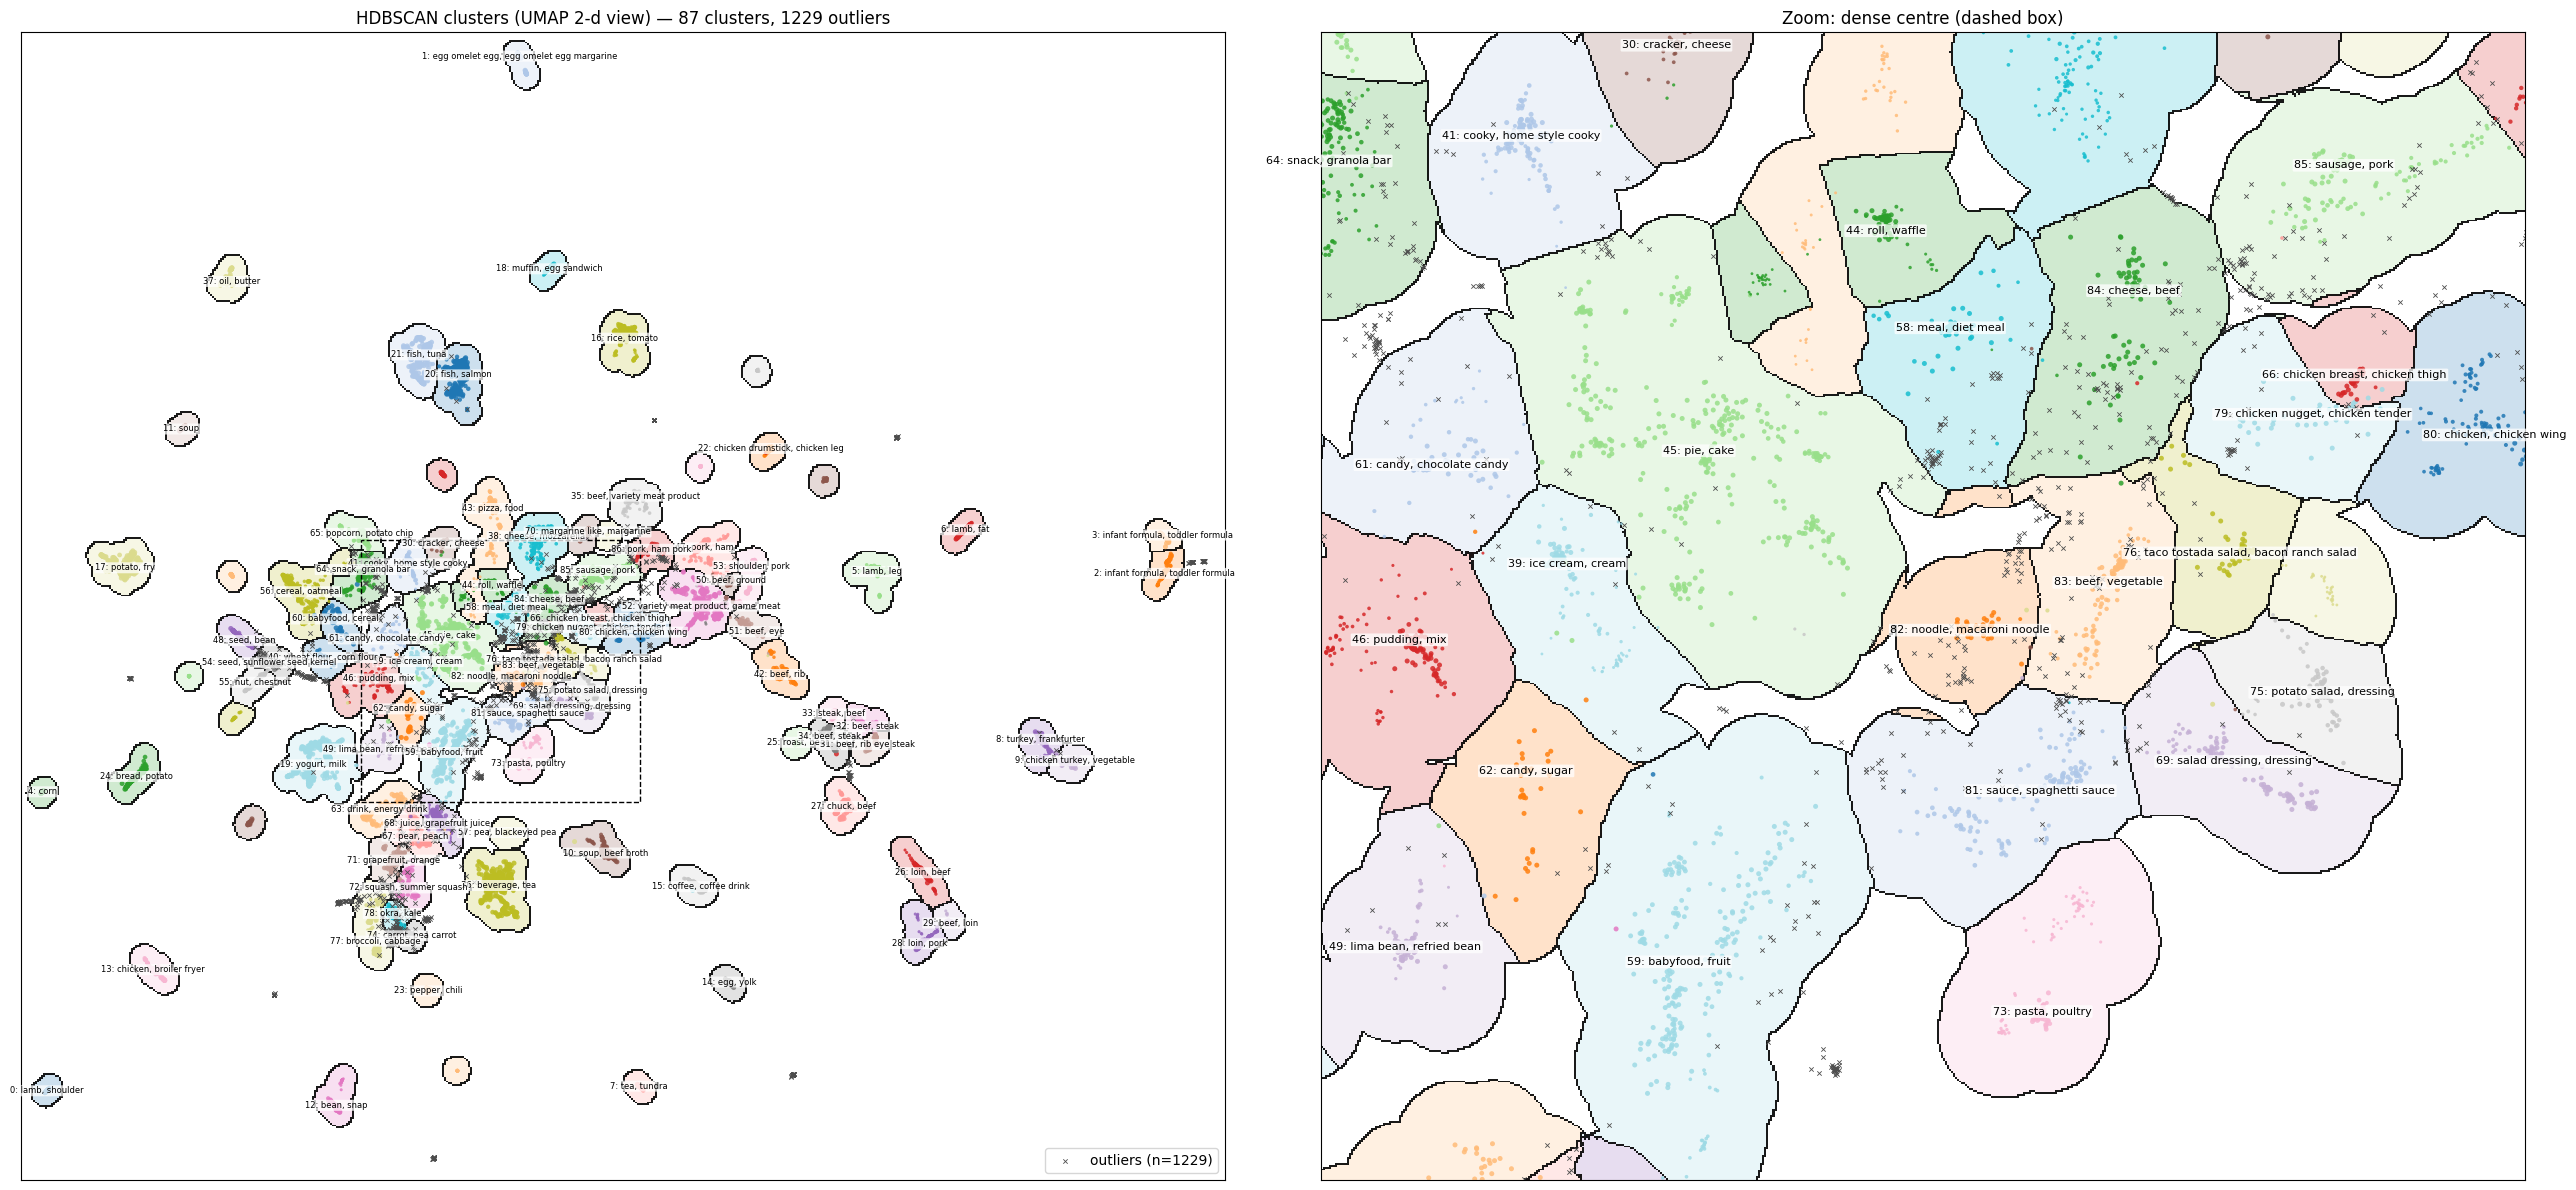

In [8]:
cmap = plt.get_cmap('tab20')
colors = {c: cmap(c % 20) for c in range(n_clusters)}
mask = labels >= 0

knn = KNeighborsClassifier(n_neighbors=15).fit(X2[mask], labels[mask])

def region_grid(xlim, ylim, res=600, max_dist=0.35):
    xx, yy = np.meshgrid(np.linspace(*xlim, res), np.linspace(*ylim, res))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = knn.predict(grid).reshape(xx.shape)
    dist, _ = knn.kneighbors(grid, n_neighbors=1)
    zz = np.where(dist.reshape(xx.shape) < max_dist, zz, -1)
    # boundary = cell whose label differs from its right/upper neighbour (and is not empty on both sides)
    edge = np.zeros_like(zz, dtype=bool)
    edge[:, :-1] |= (zz[:, :-1] != zz[:, 1:]) & ((zz[:, :-1] >= 0) | (zz[:, 1:] >= 0))
    edge[:-1, :] |= (zz[:-1, :] != zz[1:, :]) & ((zz[:-1, :] >= 0) | (zz[1:, :] >= 0))
    return zz, edge

def medoid(P):
    c = np.median(P, axis=0)
    return P[np.argmin(((P - c) ** 2).sum(1))]     # always lands on a real point

cluster_names = {c: top_tokens(df[df.cluster == c], 2) for c in range(n_clusters)}
region_cmap = plt.matplotlib.colors.ListedColormap([colors[c] for c in range(n_clusters)])

def draw_map(ax, xlim, ylim, fontsize):
    zz, edge = region_grid(xlim, ylim)
    ext = (*xlim, *ylim)
    ax.imshow(np.ma.masked_less(zz, 0), origin='lower', extent=ext, cmap=region_cmap,
              vmin=-0.5, vmax=n_clusters - 0.5, alpha=0.22, aspect='auto', interpolation='nearest')
    ax.imshow(np.ma.masked_where(~edge, edge), origin='lower', extent=ext, cmap='binary',
              vmin=0, vmax=1, alpha=0.9, aspect='auto', interpolation='nearest')
    ax.scatter(X2[mask, 0], X2[mask, 1], c=[colors[l] for l in labels[mask]],
               s=3 + 10 * df['membership'].values[mask], alpha=0.85, linewidths=0)
    ax.scatter(X2[~mask, 0], X2[~mask, 1], marker='x', c='0.3', s=10, linewidths=0.6, label=f'outliers (n={n_noise})')
    for c in range(n_clusters):
        mx, my = medoid(X2[labels == c])
        if xlim[0] < mx < xlim[1] and ylim[0] < my < ylim[1]:
            ax.text(mx, my, f'{c}: {cluster_names[c]}', fontsize=fontsize, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.75))
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_xticks([]); ax.set_yticks([])

pad = 0.5
full = ((X2[:, 0].min() - pad, X2[:, 0].max() + pad), (X2[:, 1].min() - pad, X2[:, 1].max() + pad))
lo, hi = np.percentile(X2, 30, axis=0), np.percentile(X2, 70, axis=0)
zoom = ((lo[0] - 1, hi[0] + 1), (lo[1] - 1, hi[1] + 1))

fig, axes = plt.subplots(1, 2, figsize=(26, 12), gridspec_kw={'width_ratios': [1, 1]})
draw_map(axes[0], *full, fontsize=6)
axes[0].add_patch(plt.Rectangle((zoom[0][0], zoom[1][0]), zoom[0][1] - zoom[0][0], zoom[1][1] - zoom[1][0],
                                fill=False, ls='--', ec='k'))
axes[0].set_title(f'HDBSCAN clusters (UMAP 2-d view) — {n_clusters} clusters, {n_noise} outliers')
axes[0].legend(loc='lower right')
draw_map(axes[1], *zoom, fontsize=8)
axes[1].set_title('Zoom: dense centre (dashed box)')
plt.tight_layout()
plt.show()

## 8. Outliers

Where the outliers sit and how strongly the clustered points belong to their clusters, followed by a sample of outlier recipes.

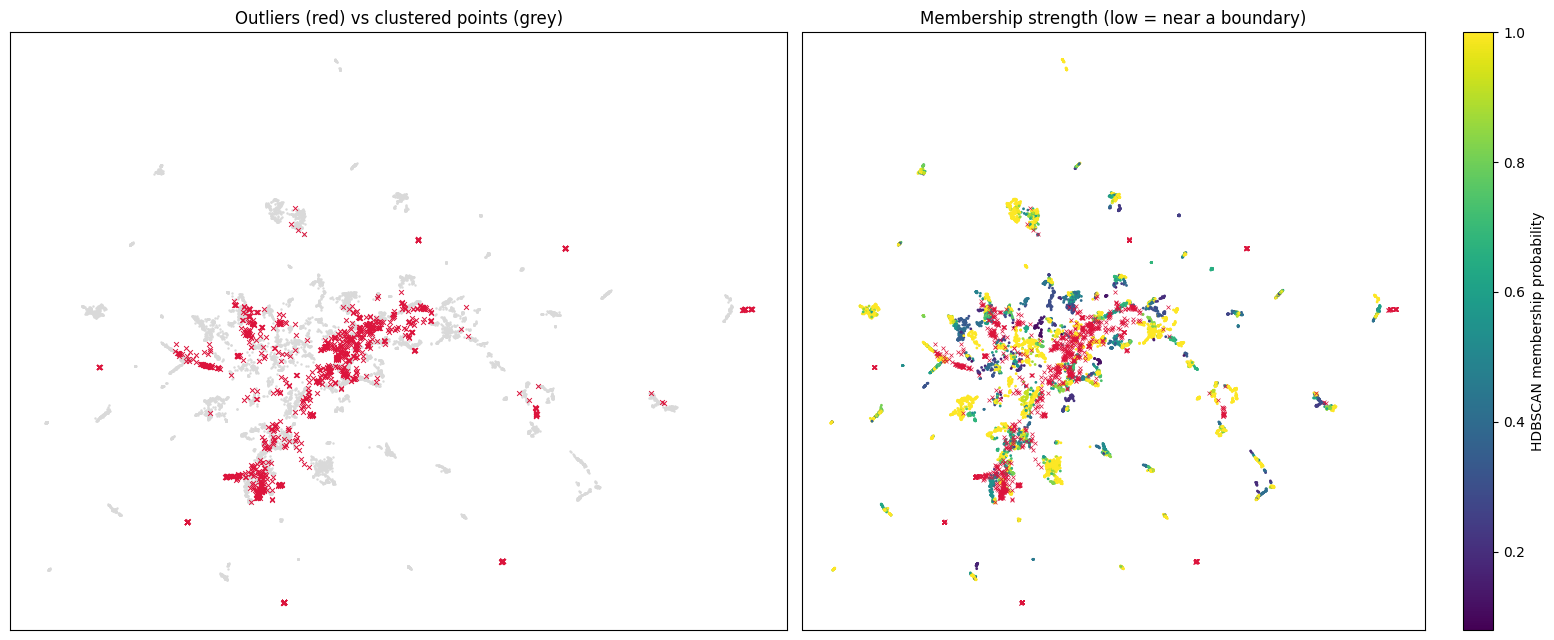

1229 outliers; share with unpriced items: 13.8% (vs 20.4% overall)


,description,product_norm,desc_norm,price_lo,price_hi,energy_kcal,protein_g,fat_g
4990,"Babyfood, dinner, macaroni and tomato and beef...",[macaroni tomato beef],[strain],10.25,10.25,61.0,2.36,1.47
10152,"Mushrooms, fresh, cooked with butter or margarine",[mushroom],"[fresh, cook]",3.30,3.30,62.0,3.52,3.16
2006,"Mushrooms, shiitake, cooked, with salt","[mushroom, shiitake]",[cook],0.30,6.30,56.0,1.56,0.22
5282,"Peanuts, spanish, oil-roasted, without salt",[peanut],"[spanish, roast]",2.38,2.38,579.0,28.01,49.04
10264,"Ginger root, pickled",[ginger root],[pickle],1.65,1.65,20.0,0.33,0.10
9762,"Potato, home fries, with vegetables","[potato, home fry]",[],10.14,10.14,173.0,1.72,11.77
7806,"Stew, chicken, with pasta","[stew, chicken]",[],5.00,11.00,108.0,10.24,2.49
5959,"CAMPBELL'S CHUNKY, Hearty Beef Barley Soup",[beef barley soup],"[chunky, hearty]",4.59,4.59,56.0,2.89,0.92
1052,"Millet, cooked",[millet],[cook],6.94,6.94,119.0,3.51,1.00
1190,"Breakfast bars, oats, sugar, raisins, coconut ...",[breakfast bar],[include],7.56,7.56,464.0,9.80,17.60


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

ax = axes[0]
ax.scatter(X2[mask, 0], X2[mask, 1], c='0.85', s=3, linewidths=0)
ax.scatter(X2[~mask, 0], X2[~mask, 1], c='crimson', marker='x', s=12, linewidths=0.7)
ax.set_title('Outliers (red) vs clustered points (grey)')
ax.set_xticks([]); ax.set_yticks([])

ax = axes[1]
sc = ax.scatter(X2[mask, 0], X2[mask, 1], c=df['membership'][mask], cmap='viridis', s=4, linewidths=0)
ax.scatter(X2[~mask, 0], X2[~mask, 1], c='crimson', marker='x', s=8, linewidths=0.5)
plt.colorbar(sc, ax=ax, label='HDBSCAN membership probability')
ax.set_title('Membership strength (low = near a boundary)')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

outliers = df[df.cluster == -1]
print(f'{len(outliers)} outliers; share with unpriced items: {(outliers.n_unpriced > 0).mean():.1%} '
      f'(vs {(df.n_unpriced > 0).mean():.1%} overall)')
outliers[['description', 'product_norm', 'desc_norm', 'price_lo', 'price_hi', 'energy_kcal', 'protein_g', 'fat_g']].sample(20, random_state=SEED)

## 9. Price interval and nutrients by cluster

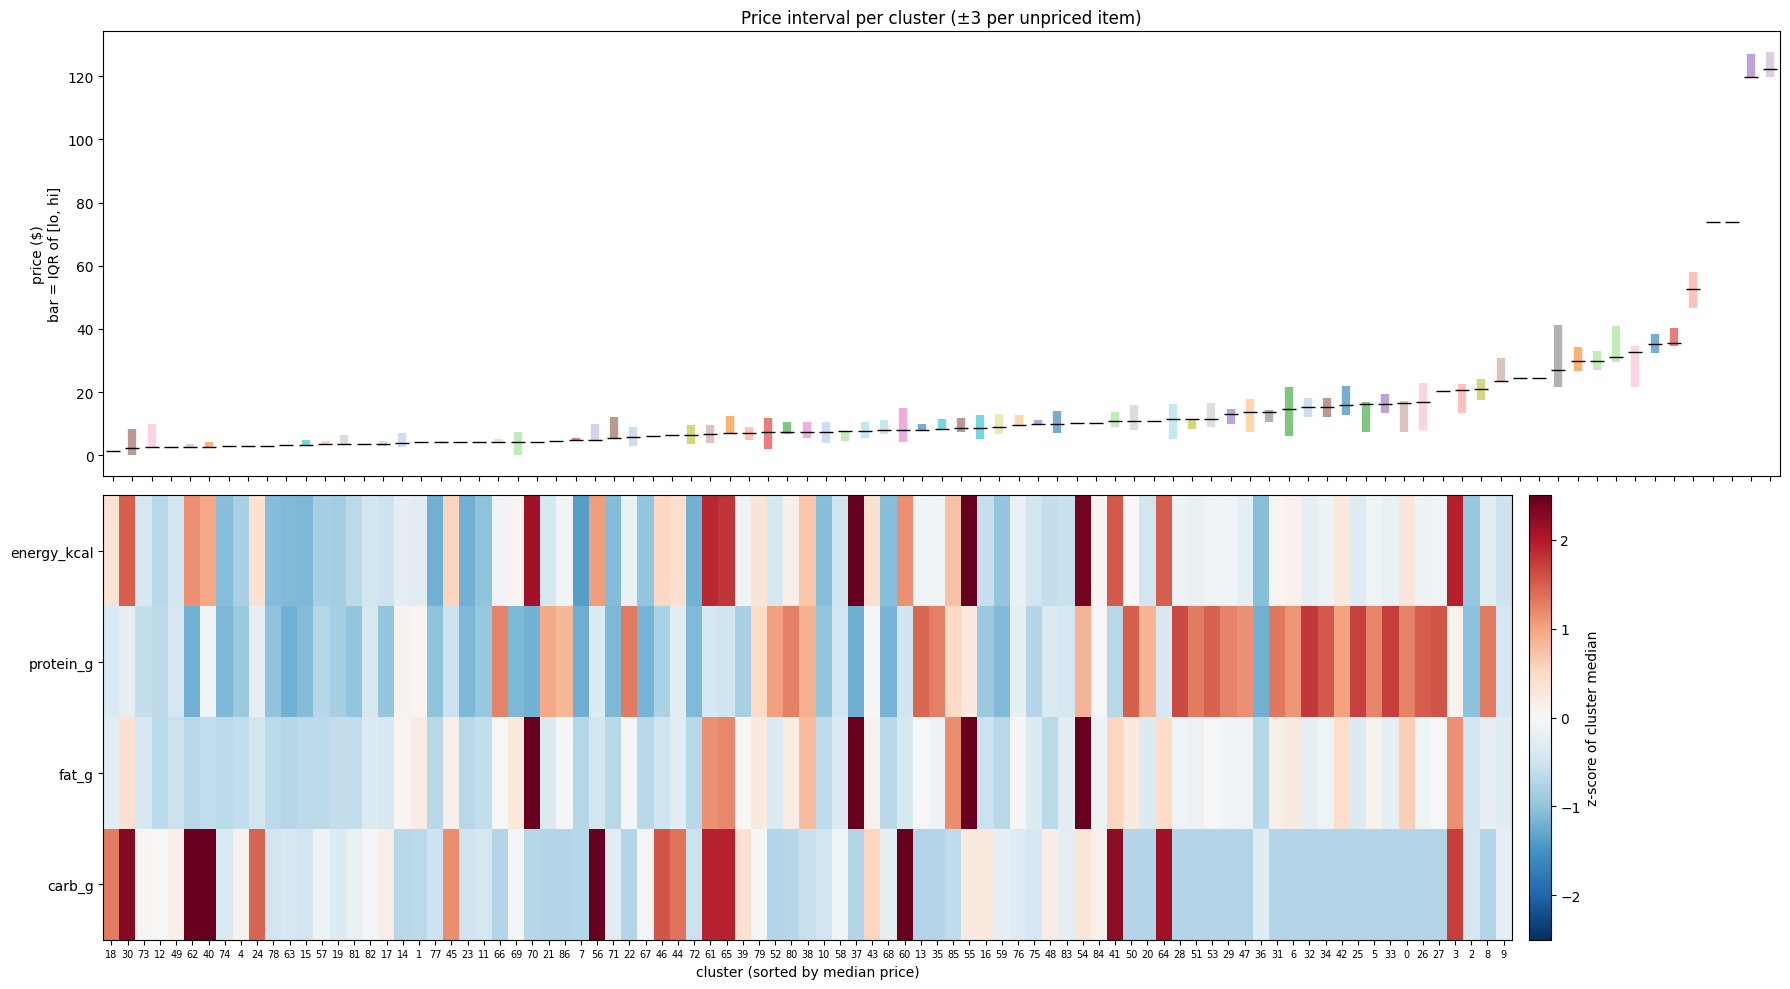

In [10]:
order = summary.sort_values('price_mid').index
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

ax = axes[0]
for i, c in enumerate(order):
    sub = df[df.cluster == c]
    ax.vlines(i, sub['price_lo'].quantile(0.25), sub['price_hi'].quantile(0.75), color=colors[c], linewidth=6, alpha=0.6)
    ax.plot(i, sub['price_mid'].median(), 'k_', markersize=10)
ax.set_ylabel('price ($)\nbar = IQR of [lo, hi]')
ax.set_title('Price interval per cluster (±3 per unpriced item)')

ax = axes[1]
z = summary.loc[order, ['energy_kcal', 'protein_g', 'fat_g', 'carb_g']]
z = (z - z.mean()) / z.std()
im = ax.imshow(z.T.values, aspect='auto', cmap='RdBu_r', vmin=-2.5, vmax=2.5)
ax.set_yticks(range(z.shape[1])); ax.set_yticklabels(z.columns)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, fontsize=7)
ax.set_xlabel('cluster (sorted by median price)')
plt.colorbar(im, ax=ax, label='z-score of cluster median', pad=0.01)
plt.tight_layout(); plt.show()

## 10. Price vs energy, coloured by cluster (error bars = unpriced uncertainty)

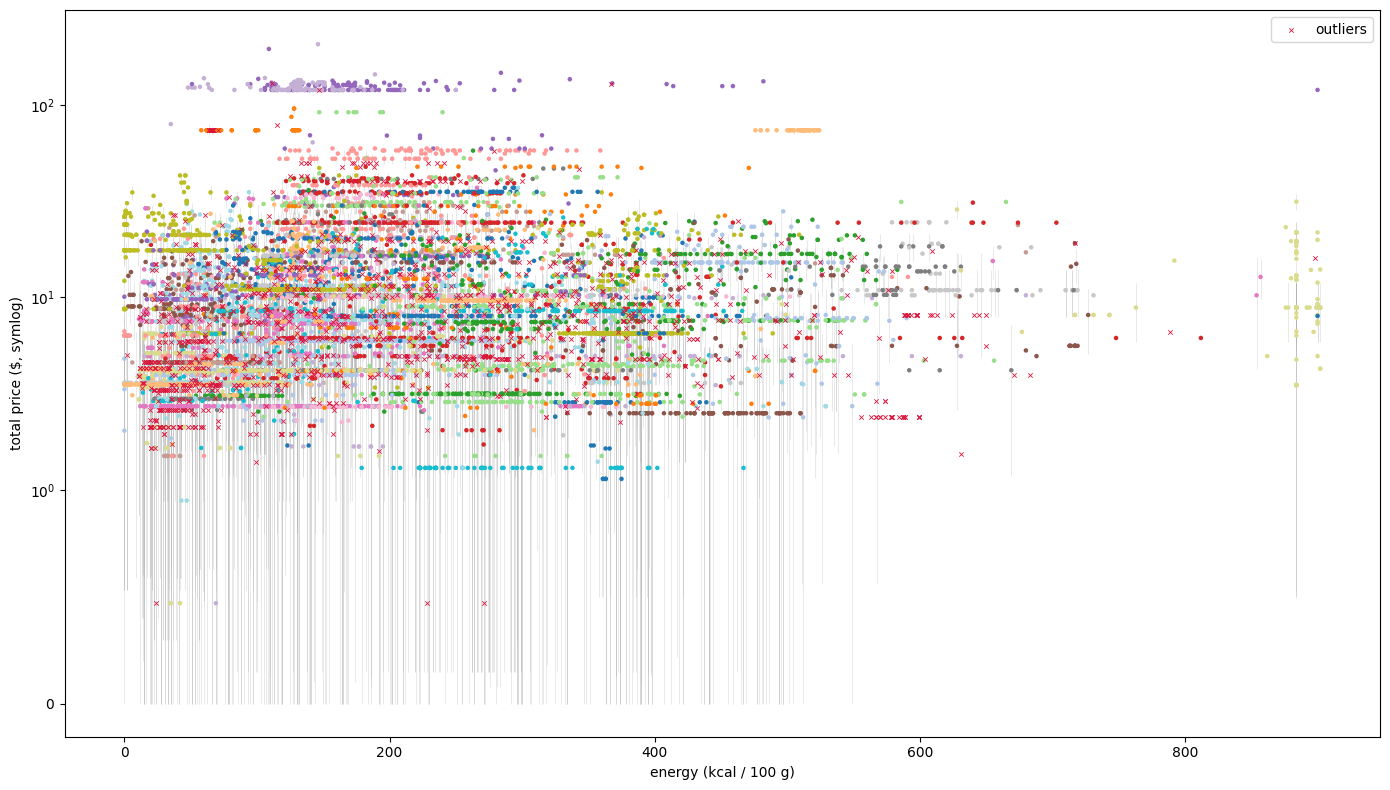

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))
unc = df['n_unpriced'] > 0
ax.errorbar(df.loc[unc, 'energy_kcal'], df.loc[unc, 'price_mid'],
            yerr=[df.loc[unc, 'price_mid'] - df.loc[unc, 'price_lo'], df.loc[unc, 'price_hi'] - df.loc[unc, 'price_mid']],
            fmt='none', ecolor='0.7', elinewidth=0.4, alpha=0.5, zorder=1)
ax.scatter(df.loc[mask, 'energy_kcal'], df.loc[mask, 'price_mid'], c=[colors[l] for l in labels[mask]], s=5, zorder=2)
ax.scatter(df.loc[~mask, 'energy_kcal'], df.loc[~mask, 'price_mid'], marker='x', c='crimson', s=10, linewidths=0.6, zorder=3, label='outliers')
ax.set_yscale('symlog', linthresh=1)
ax.set_xlabel('energy (kcal / 100 g)'); ax.set_ylabel('total price ($, symlog)')
ax.legend(); plt.tight_layout(); plt.show()

## 11. Save the clustering model for inference

sklearn's `HDBSCAN` has no `predict()` for unseen points, so the saved bundle holds the whole fitted pipeline (normalized-token embedding cache, per-block PCA/scalers, nutrient medians, 10-d UMAP, the fitted `HDBSCAN`) plus a nearest-neighbour index over the training points in 10-d UMAP space.

A new recipe goes through the same features → `umap10.transform` steps. It then takes the majority label of its 15 nearest training points; noise points (-1) take part in the vote, so a recipe that lands in a noise region becomes an outlier. A recipe is also marked -1 when its nearest clustered training point is farther away than the 99th percentile of training nearest-neighbour distances.

In [ ]:
K_ASSIGN = 15
nn_all = NearestNeighbors(n_neighbors=K_ASSIGN).fit(X10)
nn_clustered = NearestNeighbors(n_neighbors=2).fit(X10[labels >= 0])
# distance from each clustered point to its nearest *other* clustered point
d_self, _ = nn_clustered.kneighbors(X10[labels >= 0])
outlier_dist = float(np.percentile(d_self[:, 1], 99))

bundle = {
    'config': {'SEED': SEED, 'UNPRICED_BAND': UNPRICED_BAND, 'NUTRIENTS': NUTRIENTS, 'WEIGHTS': WEIGHTS,
               'PCA_DIMS': PCA_DIMS, 'ENCODER_NAME': ENCODER_NAME, 'K_ASSIGN': K_ASSIGN},
    'tok2vec': tok2vec,
    'nutr_medians': nutr_medians,
    'block_fits': block_fits,
    'umap10': umap10,
    'hdbscan': hdb,
    'train_labels': labels,
    'train_fdc_id': df['fdc_id'].values,
    'nn_all': nn_all,
    'nn_clustered': nn_clustered,
    'outlier_dist': outlier_dist,
    'cluster_names': cluster_names,
}
os.makedirs(ARTIFACT_DIR, exist_ok=True)
model_path = f'{ARTIFACT_DIR}/recipe_clustering.joblib'
joblib.dump(bundle, model_path, compress=3)

with open(model_path, 'rb') as f:
    sha = hashlib.sha256(f.read()).hexdigest()
meta = {'n_clusters': int(n_clusters), 'n_outliers': int(n_noise), 'n_train': len(df),
        'outlier_dist': outlier_dist, 'sha256': sha, 'cluster_names': {int(k): v for k, v in cluster_names.items()}}
with open(f'{ARTIFACT_DIR}/meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'saved {model_path} ({os.path.getsize(model_path) / 1e6:.1f} MB), sha256={sha[:12]}')

## 12. Inference

`predict_clusters` needs the helper functions from sections 1–4 (`parse_lists`, `normalize_tokens`, `add_price_interval`, `embed`, `raw_blocks`, `assemble`). It loads their fitted state from the bundle, so the training cells in sections 5–10 don't have to run. Tokens not seen in training are encoded on the fly. The sanity check at the end re-predicts training recipes and compares them with their HDBSCAN labels. `umap.transform` is not bit-identical to `fit_transform`, so expect high but not perfect agreement.

In [ ]:
def load_clustering(path=f'{ARTIFACT_DIR}/recipe_clustering.joblib'):
    global nutr_medians, block_fits
    b = joblib.load(path)
    tok2vec.update(b['tok2vec'])
    nutr_medians, block_fits = b['nutr_medians'], b['block_fits']
    return b

def predict_clusters(frame, b):
    """frame: rows with the columns of price_mapped_nutrients.csv (list columns may be strings).
    Returns frame with `cluster` (-1 = outlier) and `cluster_name`."""
    frame = add_price_interval(normalize_tokens(parse_lists(frame)))
    Z = b['umap10'].transform(assemble(raw_blocks(frame, *embed(frame))))

    _, idx = b['nn_all'].kneighbors(Z)
    votes = b['train_labels'][idx]
    pred = np.array([np.bincount(v + 1).argmax() - 1 for v in votes])   # +1 shift so -1 can vote
    d_near, _ = b['nn_clustered'].kneighbors(Z, n_neighbors=1)
    pred[d_near[:, 0] > b['outlier_dist']] = -1

    frame['cluster'] = pred
    frame['cluster_name'] = [b['cluster_names'].get(c, 'outlier') for c in pred]
    return frame

clustering = load_clustering()
sample = pd.read_csv('input_stage2/price_mapped_nutrients.csv').sample(500, random_state=SEED)
pred = predict_clusters(sample, clustering)
truth = df.set_index('fdc_id').loc[pred['fdc_id'], 'cluster'].values
print(f'agreement with training labels on {len(pred)} recipes: {(pred["cluster"].values == truth).mean():.1%}')
pred[['description', 'cluster', 'cluster_name']].head(10)

In [12]:
df.drop(columns=['item_prices']).to_csv('output/recipe_clusters.csv', index=False)